In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Real Sociedad"
away= "Mallorca"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Real Sociedad,Barcelona,2025-03-02,L,A,0,4,-4,0,0,...,0.0,0.1,0.0,0.0,0.0,NaN,0,2.7,0.27,-1.3
26,Real Sociedad,Sevilla,2025-03-09,L,H,0,1,-1,0,0,...,0.6,0.5,-0.7,-0.7,-0.6,0.10,0,1.1,0.28,0.1
27,Real Sociedad,Rayo Vallecano,2025-03-16,D,A,2,2,0,0,0,...,0.3,0.5,1.4,1.4,0.7,0.07,1,0.8,0.16,-1.2
28,Real Sociedad,Valladolid,2025-03-29,W,H,2,1,1,0,0,...,0.6,1.0,1.3,1.3,0.4,0.06,1,1.0,0.21,0.0
29,Real Sociedad,Las Palmas,2025-04-06,W,A,3,1,2,0,0,...,1.6,1.2,0.6,0.6,-0.6,0.19,0,1.8,0.35,0.8


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Barcelona,Real Sociedad,2025-03-02,W,H,4,0,4,0,0,...,2.0,3.2,1.2,1.2,1.0,0.09,2,0.0,NaN,0.0
26,Sevilla,Real Sociedad,2025-03-09,W,A,1,0,1,0,0,...,0.4,0.6,0.4,0.4,0.6,0.07,0,0.9,0.44,0.9
27,Rayo Vallecano,Real Sociedad,2025-03-16,D,H,2,2,0,0,0,...,0.4,0.5,1.4,1.4,1.6,0.06,1,1.0,0.24,-1.0
28,Valladolid,Real Sociedad,2025-03-29,L,A,1,2,-1,0,0,...,0.6,0.7,0.3,0.3,0.4,0.06,0,0.5,0.23,-1.5
29,Las Palmas,Real Sociedad,2025-04-06,L,H,1,3,-2,0,0,...,1.6,1.7,-1.0,-1.0,-0.6,0.15,0,2.4,0.31,-0.6


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Mallorca,Alavés,2025-03-02,D,H,1,1,0,0,0,...,1.1,0.5,-0.1,-0.1,-0.1,0.08,0,2.0,0.29,1.0
26,Mallorca,Athletic Club,2025-03-09,D,A,1,1,0,0,0,...,0.5,0.4,0.5,0.5,0.5,0.06,0,0.2,0.11,-0.8
27,Mallorca,Espanyol,2025-03-15,W,H,2,1,1,1,1,...,1.1,1.2,-0.7,-0.1,-0.1,0.06,0,0.0,NaN,0.0
28,Mallorca,Valencia,2025-03-30,L,A,0,1,-1,0,0,...,0.5,0.4,-0.6,-0.6,-0.5,0.07,0,1.1,0.54,0.1
29,Mallorca,Celta Vigo,2025-04-05,L,H,1,2,-1,0,0,...,0.5,0.6,0.5,0.5,0.5,0.08,0,1.7,0.42,-0.3


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Alavés,Mallorca,2025-03-02,D,A,1,1,0,0,0,...,1.6,0.7,-0.6,-0.6,-0.6,0.09,0,0.9,0.22,-0.1
26,Athletic Club,Mallorca,2025-03-09,D,H,1,1,0,0,0,...,0.7,0.8,0.3,0.3,0.3,0.09,1,0.6,0.29,-0.4
27,Espanyol,Mallorca,2025-03-15,L,A,1,2,-1,0,0,...,0.2,0.1,-0.2,-0.2,-0.2,0.10,0,2.8,0.18,0.8
28,Valencia,Mallorca,2025-03-30,W,H,1,0,1,0,0,...,0.6,0.9,0.3,0.3,0.4,0.09,0,0.1,0.05,0.1
29,Celta Vigo,Mallorca,2025-04-05,W,A,2,1,1,0,0,...,0.5,0.5,1.2,1.2,1.5,0.08,1,0.8,0.41,-0.2


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'PK', 'PKm', 'G-PK', 'Poss', 'PKatt', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,0,0,24,0,15,5,33.3,10,66.7,...,-2.8,-2.8,0.0,0.1,0.0,0.0,0.0,NaN,0,0
26,0,0,0,61,0,17,9,52.9,6,35.3,...,0.1,0.1,0.6,0.5,-0.7,-0.7,-0.6,0.10,0,0
27,2,0,0,45,0,25,15,60.0,8,32.0,...,0.0,0.0,0.3,0.5,1.4,1.4,0.7,0.07,1,2
28,2,0,0,55,0,15,6,40.0,6,40.0,...,0.0,0.0,0.6,1.0,1.3,1.3,0.4,0.06,1,2
29,3,0,0,49,0,16,7,43.8,7,43.8,...,0.4,0.4,1.6,1.2,0.6,0.6,-0.6,0.19,0,3


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,4,0,0,76,0,18,8,44.4,8,44.4,...,2.8,2.8,2.0,3.2,1.2,1.2,1.0,0.09,2,4
26,1,0,0,39,0,8,3,37.5,3,37.5,...,-0.1,-0.1,0.4,0.6,0.4,0.4,0.6,0.07,0,1
27,2,0,0,55,0,21,6,28.6,12,57.1,...,0.0,0.0,0.4,0.5,1.4,1.4,1.6,0.06,1,2
28,1,0,0,45,0,25,11,44.0,10,40.0,...,0.0,0.0,0.6,0.7,0.3,0.3,0.4,0.06,0,1
29,1,0,0,51,0,15,6,40.0,7,46.7,...,-0.4,-0.4,1.6,1.7,-1.0,-1.0,-0.6,0.15,0,1


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,44,0,18,6,33.3,8,44.4,...,-0.5,-0.5,1.1,0.5,-0.1,-0.1,-0.1,0.08,0,1
26,1,0,0,45,0,7,5,71.4,2,28.6,...,-0.2,-0.2,0.5,0.4,0.5,0.5,0.5,0.06,0,1
27,1,1,1,62,2,17,5,29.4,7,41.2,...,2.5,0.9,1.1,1.2,-0.7,-0.1,-0.1,0.06,0,2
28,0,0,0,56,0,17,5,29.4,11,64.7,...,-0.1,-0.1,0.5,0.4,-0.6,-0.6,-0.5,0.07,0,0
29,1,0,0,45,0,6,2,33.3,3,50.0,...,-0.3,-0.3,0.5,0.6,0.5,0.5,0.5,0.08,0,1


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,56,0,18,5,27.8,9,50.0,...,0.5,0.5,1.6,0.7,-0.6,-0.6,-0.6,0.09,0,1
26,1,0,0,55,0,21,10,47.6,10,47.6,...,0.2,0.2,0.7,0.8,0.3,0.3,0.3,0.09,1,1
27,0,0,0,38,0,12,5,41.7,6,50.0,...,-2.5,-0.9,0.2,0.1,-0.2,-0.2,-0.2,0.10,0,1
28,1,0,0,44,0,18,7,38.9,9,50.0,...,0.1,0.1,0.6,0.9,0.3,0.3,0.4,0.09,0,1
29,2,0,0,55,0,14,5,35.7,8,57.1,...,0.3,0.3,0.5,0.5,1.2,1.2,1.5,0.08,1,2


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,17,0,0.0,0,0,2.5,0,NaN,0,2,...,13,8,8,23,35,1,2.7,0.27,-1.3,4
26,10,1,10.0,0,3,23.0,0,NaN,0,0,...,1,3,4,10,13,0,1.1,0.28,0.1,1
27,18,3,16.7,0,3,11.8,0,NaN,0,0,...,2,6,7,27,37,0,0.8,0.16,-1.2,2
28,18,1,5.6,0,2,18.0,0,NaN,0,0,...,2,12,3,25,36,1,1.0,0.21,0.0,1
29,18,1,5.6,0,0,10.2,0,NaN,0,0,...,4,2,5,18,45,1,1.8,0.35,0.8,1


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,1,0,0.0,0,2,19.5,0,NaN,0,0,...,0,4,7,23,7,0,0.0,NaN,0.0,0
26,24,1,4.2,0,0,9.7,0,NaN,0,0,...,0,14,10,22,38,1,0.9,0.44,0.9,0
27,11,1,9.1,0,0,9.3,0,NaN,0,1,...,2,8,10,25,37,0,1.0,0.24,-1.0,2
28,14,1,7.1,0,1,11.4,0,NaN,1,0,...,5,8,4,16,21,2,0.5,0.23,-1.5,2
29,8,0,0.0,0,1,13.5,0,NaN,0,0,...,2,8,9,25,14,0,2.4,0.31,-0.6,3


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,9,0,0.0,0,0,3.5,0,NaN,0,0,...,3,8,14,32,29,0,1.2,0.25,0.2,1
1,17,0,0.0,0,0,8.3,0,NaN,0,0,...,3,7,6,29,45,1,0.6,0.12,-0.4,1
2,16,0,0.0,0,0,NaN,0,NaN,0,0,...,3,5,8,21,27,0,1.0,0.14,1.0,0
3,12,0,0.0,0,1,17.5,0,NaN,0,0,...,1,4,15,28,32,0,0.0,0.01,0.0,0
4,15,1,6.7,0,0,4.0,0,NaN,0,1,...,7,8,4,19,12,0,2.0,0.51,0.0,2


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,21,1,4.8,0,0,4.5,0,NaN,0,1,...,1,6,4,19,23,0,0.6,0.12,-0.4,1
1,20,2,10.0,0,0,7.0,0,NaN,0,0,...,5,10,10,33,19,0,0.1,0.06,0.1,0
2,20,1,5.0,0,1,11.6,0,NaN,0,0,...,2,8,8,21,28,0,0.9,0.22,0.9,0
3,15,1,6.7,0,0,10.2,0,NaN,0,0,...,4,7,14,29,27,0,1.2,0.39,0.2,1
4,27,2,7.4,0,0,6.0,0,NaN,0,0,...,2,7,6,16,28,0,0.3,0.08,0.3,1


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,11,8,57.9,0,1,0,6,13,25
26,9,23,28.1,2,0,0,14,11,32
27,14,23,37.8,2,0,0,9,14,51
28,9,20,31.0,2,0,0,20,10,42
29,16,17,48.5,2,0,0,10,8,36


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,8,11,42.1,0,0,0,15,6,40
26,23,9,71.9,1,0,0,12,14,40
27,23,14,62.2,3,0,0,16,9,61
28,20,9,69.0,3,0,0,10,19,39
29,17,16,51.5,0,0,0,8,10,41


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,30,21,58.8,0,0,0,20,13,34
26,20,20,50.0,3,0,0,13,6,37
27,14,16,46.7,0,0,0,10,12,46
28,7,28,20.0,4,0,0,15,16,41
29,14,12,53.8,3,0,0,9,11,41


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,21,30,41.2,2,0,0,14,19,42
26,20,20,50.0,1,0,0,6,12,45
27,16,14,53.3,2,0,0,12,9,27
28,28,7,80.0,4,0,0,16,14,39
29,12,14,46.2,0,0,0,11,9,44


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,0,0,24,0,15,5,33.3,10,66.7,...,0.325,1.419800,0.275,1.454590,0.105000,0.047958,0.50,1.00000,1.50,1.290994
26,0,0,0,61,0,17,9,52.9,6,35.3,...,0.575,1.175798,0.500,1.270171,0.086667,0.037859,0.50,1.00000,1.25,1.500000
27,2,0,0,45,0,25,15,60.0,8,32.0,...,0.325,1.347529,0.400,1.356466,0.076667,0.020817,0.00,0.00000,0.75,1.500000
28,2,0,0,55,0,15,6,40.0,6,40.0,...,0.750,1.352775,0.625,1.297112,0.076667,0.020817,0.25,0.50000,1.25,1.500000
29,3,0,0,49,0,16,7,43.8,7,43.8,...,0.500,1.023067,0.125,0.561991,0.076667,0.020817,0.50,0.57735,1.00,1.154701


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,4,0,0,76,0,18,8,44.4,8,44.4,...,0.600,0.930949,0.375,0.834166,0.0475,0.020616,0.25,0.500000,1.50,1.290994
26,1,0,0,39,0,8,3,37.5,3,37.5,...,0.575,0.906918,0.225,0.543906,0.0550,0.030000,0.75,0.957427,2.00,1.825742
27,2,0,0,55,0,21,6,28.6,12,57.1,...,0.700,0.812404,0.400,0.516398,0.0650,0.025166,0.75,0.957427,2.00,1.825742
28,1,0,0,45,0,25,11,44.0,10,40.0,...,0.675,0.780491,0.750,0.754983,0.0625,0.025000,0.75,0.957427,1.75,1.707825
29,1,0,0,51,0,15,6,40.0,7,46.7,...,0.825,0.556028,0.900,0.529150,0.0700,0.014142,0.75,0.957427,2.00,1.414214


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,29,1,3.4,0,1,15.8,0,0.0,0,1,...,0.5,1.0,1.125,0.320156,0.302500,0.048563,-0.125,0.189297,1.25,0.5
26,18,0,0.0,0,1,23.0,0,0.0,0,0,...,0.0,0.0,1.225,0.518813,0.292500,0.045000,0.225,0.518813,1.00,0.0
27,6,0,0.0,0,2,24.5,0,0.0,0,0,...,0.0,0.0,1.025,0.741058,0.240000,0.095917,0.025,0.741058,1.00,0.0
28,15,0,0.0,0,0,20.5,0,0.0,0,0,...,0.0,0.0,0.800,0.909212,0.243333,0.117189,0.050,0.737111,1.00,0.0
29,10,0,0.0,0,0,13.0,0,0.0,0,0,...,0.0,0.0,0.825,0.917878,0.313333,0.215948,0.075,0.736546,1.00,0.0


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,15,1,6.7,0,0,12.3,0,0.0,0,0,...,1.25,1.500000,1.000,0.909212,0.2425,0.257213,-0.250,0.378594,1.25,1.258306
26,13,2,15.4,0,0,7.3,0,0.0,0,1,...,1.25,1.500000,1.225,0.655108,0.2925,0.215619,-0.275,0.359398,1.50,1.000000
27,21,3,14.3,2,1,9.7,1,50.0,0,0,...,1.50,1.290994,1.175,0.704154,0.3600,0.125167,-0.325,0.359398,1.50,1.000000
28,21,2,9.5,0,0,10.0,0,0.0,0,0,...,0.75,0.957427,1.325,0.997914,0.2925,0.133010,0.075,0.512348,1.25,0.500000
29,9,0,0.0,0,3,13.3,0,0.0,0,0,...,0.25,0.500000,1.100,1.180395,0.1850,0.100830,0.100,0.509902,1.00,0.816497


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,44,0,18,6,33.3,8,44.4,...,-0.250,1.100000,-0.425,0.991211,0.1000,0.062716,0.25,0.5,1.25,1.258306
26,1,0,0,45,0,7,5,71.4,2,28.6,...,-0.150,1.087811,-0.325,1.001249,0.1075,0.056199,0.25,0.5,1.50,1.000000
27,1,1,1,62,2,17,5,29.4,7,41.2,...,0.100,1.095445,-0.150,1.087811,0.1100,0.052915,0.00,0.0,1.50,1.000000
28,0,0,0,56,0,17,5,29.4,11,64.7,...,-0.250,0.754983,-0.350,0.943398,0.0950,0.057446,0.00,0.0,1.25,0.500000
29,1,0,0,45,0,6,2,33.3,3,50.0,...,-0.075,0.450000,-0.050,0.412311,0.0675,0.009574,0.00,0.0,1.00,0.816497


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,56,0,18,5,27.8,9,50.0,...,0.050,0.506623,-0.125,0.830161,0.0825,0.009574,0.25,0.5,1.25,0.5
26,1,0,0,55,0,21,10,47.6,10,47.6,...,-0.275,0.340343,-0.500,0.476095,0.0850,0.010000,0.00,0.0,1.00,0.0
27,0,0,0,38,0,12,5,41.7,6,50.0,...,-0.100,0.424264,-0.225,0.556028,0.0850,0.010000,0.25,0.5,1.00,0.0
28,1,0,0,44,0,18,7,38.9,9,50.0,...,-0.200,0.374166,-0.325,0.485627,0.0875,0.012583,0.25,0.5,1.00,0.0
29,2,0,0,55,0,14,5,35.7,8,57.1,...,-0.050,0.435890,-0.025,0.464579,0.0925,0.005000,0.25,0.5,1.00,0.0


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,17,0,0.0,0,0,2.5,0,0.0,0,2,...,0.25,0.50000,1.175,0.826136,0.1825,0.126326,-0.325,0.718215,1.50,1.290994
26,10,1,10.0,0,3,23.0,0,0.0,0,0,...,0.25,0.50000,1.625,1.078193,0.1925,0.132759,-0.375,0.793200,2.00,1.825742
27,18,3,16.7,0,3,11.8,0,0.0,0,0,...,0.25,0.50000,1.700,1.009950,0.2625,0.035940,-0.300,0.828654,2.00,1.825742
28,18,1,5.6,0,2,18.0,0,0.0,0,0,...,0.25,0.50000,1.300,0.955685,0.2500,0.060553,-0.450,0.946925,1.75,1.707825
29,18,1,5.6,0,0,10.2,0,0.0,0,0,...,0.50,0.57735,1.400,0.875595,0.2300,0.055976,-0.600,0.752773,2.00,1.414214


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,1,0,0.0,0,2,19.5,0,0.0,0,0,...,0.00,0.000000,0.925,0.704154,0.370000,0.195192,-0.575,1.030776,1.50,1.290994
26,24,1,4.2,0,0,9.7,0,0.0,0,0,...,0.00,0.000000,0.650,0.818535,0.365000,0.275772,-0.600,1.009950,1.25,1.500000
27,11,1,9.1,0,0,9.3,0,0.0,0,1,...,0.25,0.500000,0.450,0.519615,0.305000,0.190919,-0.300,1.272792,0.75,1.500000
28,14,1,7.1,0,1,11.4,0,0.0,1,0,...,0.25,0.500000,0.700,0.469042,0.283333,0.140119,-0.550,1.292285,1.25,1.500000
29,8,0,0.0,0,1,13.5,0,0.0,0,0,...,0.75,0.957427,0.600,0.454606,0.303333,0.118462,-0.400,1.067708,1.00,1.154701


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
25,11,8,57.9,0,1,0,6,13,25,17.50,...,0.50,1.000000,0.0,0.0,11.75,2.986079,11.25,2.872281,44.25,8.341663
26,9,23,28.1,2,0,0,14,11,32,15.25,...,0.75,0.957427,0.0,0.0,11.25,3.862210,12.25,2.500000,39.00,12.463279
27,14,23,37.8,2,0,0,9,14,51,14.50,...,0.75,0.957427,0.0,0.0,12.00,4.082483,11.25,1.707825,34.50,10.214369
28,9,20,31.0,2,0,0,20,10,42,13.25,...,0.25,0.500000,0.0,0.0,10.50,3.696846,12.50,1.290994,39.25,12.763881
29,16,17,48.5,2,0,0,10,8,36,10.75,...,0.25,0.500000,0.0,0.0,12.25,6.130525,12.00,1.825742,37.50,11.387127


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
25,8,11,42.1,0,0,0,15,6,40,17.00,...,0.0,0.0,0.0,0.0,12.25,3.593976,11.75,2.986079,42.00,8.164966
26,23,9,71.9,1,0,0,12,14,40,14.25,...,0.0,0.0,0.0,0.0,13.50,3.415650,11.25,3.862210,40.00,7.118052
27,23,14,62.2,3,0,0,16,9,61,15.50,...,0.0,0.0,0.0,0.0,12.25,2.500000,12.00,4.082483,42.50,3.000000
28,20,9,69.0,3,0,0,10,19,39,16.25,...,0.0,0.0,0.0,0.0,14.00,1.825742,10.50,3.696846,46.75,9.912114
29,17,16,51.5,0,0,0,8,10,41,18.50,...,0.0,0.0,0.0,0.0,13.25,2.753785,12.00,5.715476,45.00,10.677078


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
25,30,21,58.8,0,0,0,20,13,34,17.75,...,0.0,0.0,0.0,0.0,10.00,3.559026,10.50,2.081666,41.75,7.804913
26,20,20,50.0,3,0,0,13,6,37,21.00,...,0.0,0.0,0.0,0.0,11.50,6.137318,11.75,1.500000,42.50,6.454972
27,14,16,46.7,0,0,0,10,12,46,21.75,...,0.0,0.0,0.0,0.0,13.00,5.354126,10.50,3.316625,39.75,5.619905
28,7,28,20.0,4,0,0,15,16,41,19.50,...,0.0,0.0,0.0,0.0,13.75,4.349329,10.25,3.095696,39.50,5.196152
29,14,12,53.8,3,0,0,9,11,41,17.75,...,0.0,0.0,0.0,0.0,14.50,4.203173,11.75,4.193249,39.50,5.196152


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
25,21,30,41.2,2,0,0,14,19,42,16.00,...,0.0,0.0,0.0,0.0,11.00,1.632993,9.75,3.862210,40.75,7.932003
26,20,20,50.0,1,0,0,6,12,45,18.50,...,0.0,0.0,0.0,0.0,12.25,1.500000,11.00,5.944185,40.00,7.527727
27,16,14,53.3,2,0,0,12,9,27,18.50,...,0.0,0.0,0.0,0.0,11.00,3.559026,12.50,4.932883,41.75,7.719024
28,28,7,80.0,4,0,0,16,14,39,18.50,...,0.0,0.0,0.0,0.0,10.75,3.403430,13.00,4.242641,40.75,9.604686
29,12,14,46.2,0,0,0,11,9,44,21.25,...,0.0,0.0,0.0,0.0,12.00,4.320494,13.50,4.203173,38.25,7.889867


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,3,0,0,49,0,16,7,43.8,7,43.8,...,0.0,0.825,0.917878,0.313333,0.215948,0.075,0.736546,1.0,0.0,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,0,66,0,13,6,46.2,5,38.5,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,1,0,0,66,0,15,6,40.0,8,53.3,...,0.0,0.0,11.000000,0.000000,6.000000,0.000000,42.000000,0.000000,H,1
2,1,0,0,53,0,18,7,38.9,9,50.0,...,0.0,0.0,9.500000,2.121320,8.000000,2.828427,41.000000,1.414214,A,0
3,0,0,0,47,0,14,4,28.6,9,64.3,...,0.0,0.0,11.333333,3.511885,8.333333,2.081666,40.666667,1.154701,H,0
4,0,0,0,48,0,13,4,30.8,7,53.8,...,0.0,0.0,12.750000,4.031129,8.750000,1.892969,38.750000,3.947573,A,0


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,18,1,5.6,0,0,10.2,0,0.0,0,0,...,0.0,0.0,0.0,14.5,4.203173,11.75,4.193249,39.5,5.196152,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,9,1,11.1,0,1,13.0,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,14,0,0.0,0,1,19.0,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,6.000000,0.000000,42.000000,0.000000,H,2
2,18,1,5.6,1,3,23.3,0,0.0,0,0,...,0.0,0.0,9.500000,2.121320,8.000000,2.828427,41.000000,1.414214,A,0
3,19,1,5.3,0,0,5.0,0,0.0,0,0,...,0.0,0.0,11.333333,3.511885,8.333333,2.081666,40.666667,1.154701,H,2
4,10,0,0.0,2,2,18.6,0,0.0,0,0,...,0.0,0.0,12.750000,4.031129,8.750000,1.892969,38.750000,3.947573,A,1


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,1,0,0,45,0,6,2,33.3,3,50.0,...,0.0,0.0,0.0,14.5,4.203173,11.75,4.193249,39.5,5.196152,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,0,34,0,15,6,40.0,9,60.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,0,0,0,54,0,24,9,37.5,14,58.3,...,0.0,0.0,11.000000,0.000000,6.000000,0.000000,42.000000,0.000000,H,0
2,0,0,0,45,0,10,6,60.0,3,30.0,...,0.0,0.0,9.500000,2.121320,8.000000,2.828427,41.000000,1.414214,A,1
3,1,0,0,46,0,10,3,30.0,6,60.0,...,0.0,0.0,11.333333,3.511885,8.333333,2.081666,40.666667,1.154701,H,1
4,0,0,0,53,0,12,4,33.3,6,50.0,...,0.0,0.0,12.750000,4.031129,8.750000,1.892969,38.750000,3.947573,H,1


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,10,0,0.0,0,0,13.0,0,0.0,0,0,...,0.0,0.0,0.0,14.5,4.203173,11.75,4.193249,39.5,5.196152,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,9,0,0.0,0,0,3.5,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,17,0,0.0,0,0,8.3,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,6.000000,0.000000,42.000000,0.000000,H,0
2,16,0,0.0,0,0,0.0,0,0.0,0,0,...,0.0,0.0,9.500000,2.121320,8.000000,2.828427,41.000000,1.414214,A,0
3,12,0,0.0,0,1,17.5,0,0.0,0,0,...,0.0,0.0,11.333333,3.511885,8.333333,2.081666,40.666667,1.154701,H,2
4,15,1,6.7,0,0,4.0,0,0.0,0,1,...,0.0,0.0,12.750000,4.031129,8.750000,1.892969,38.750000,3.947573,H,0


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

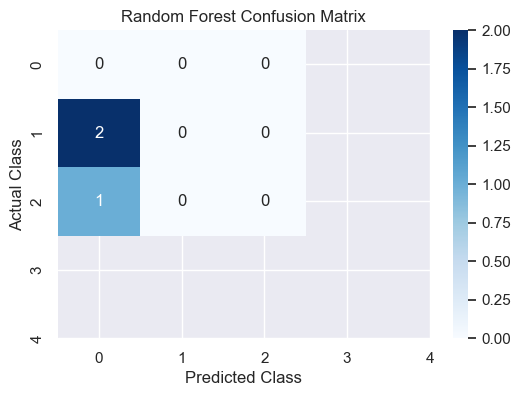

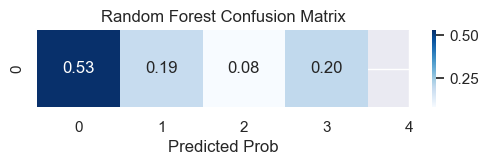

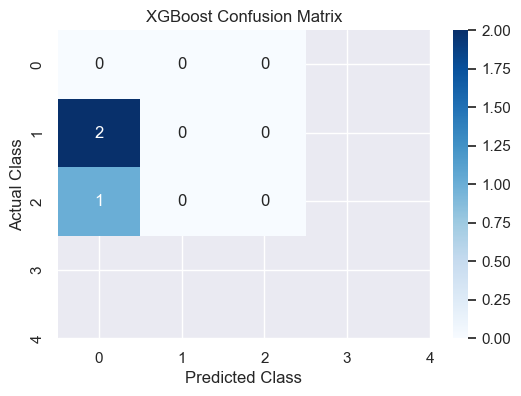

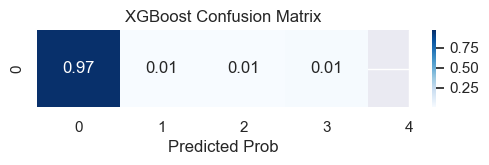

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

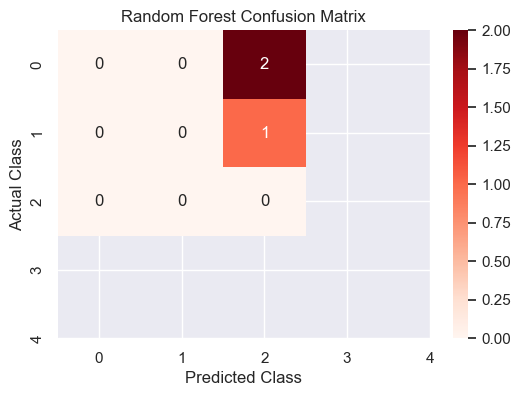

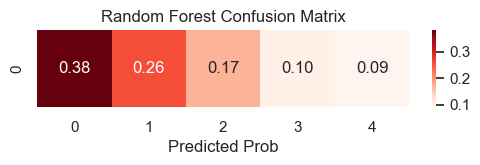

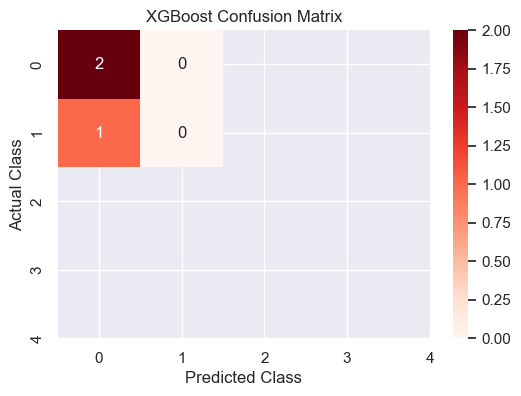

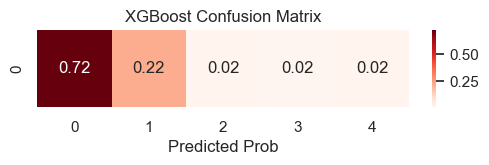

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

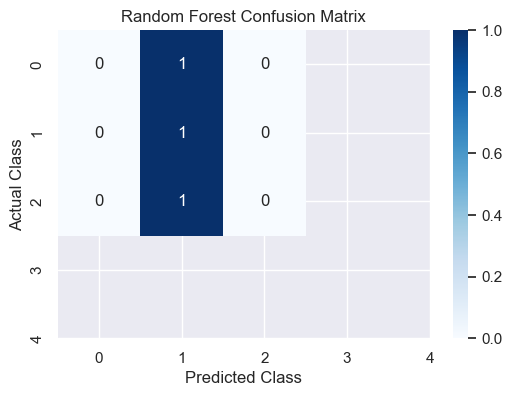

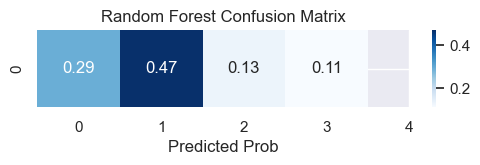

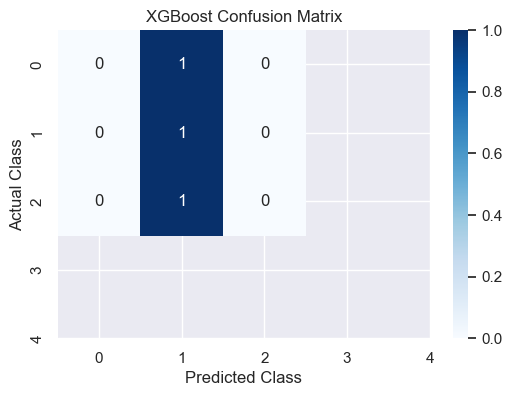

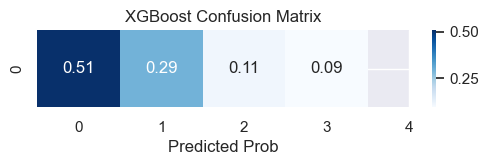

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

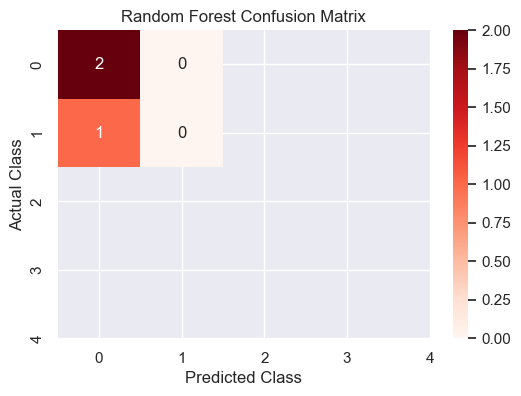

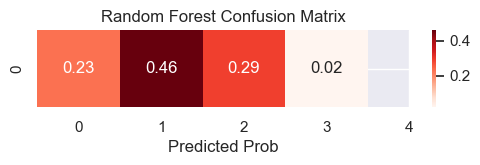

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [0 1 2 4]

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

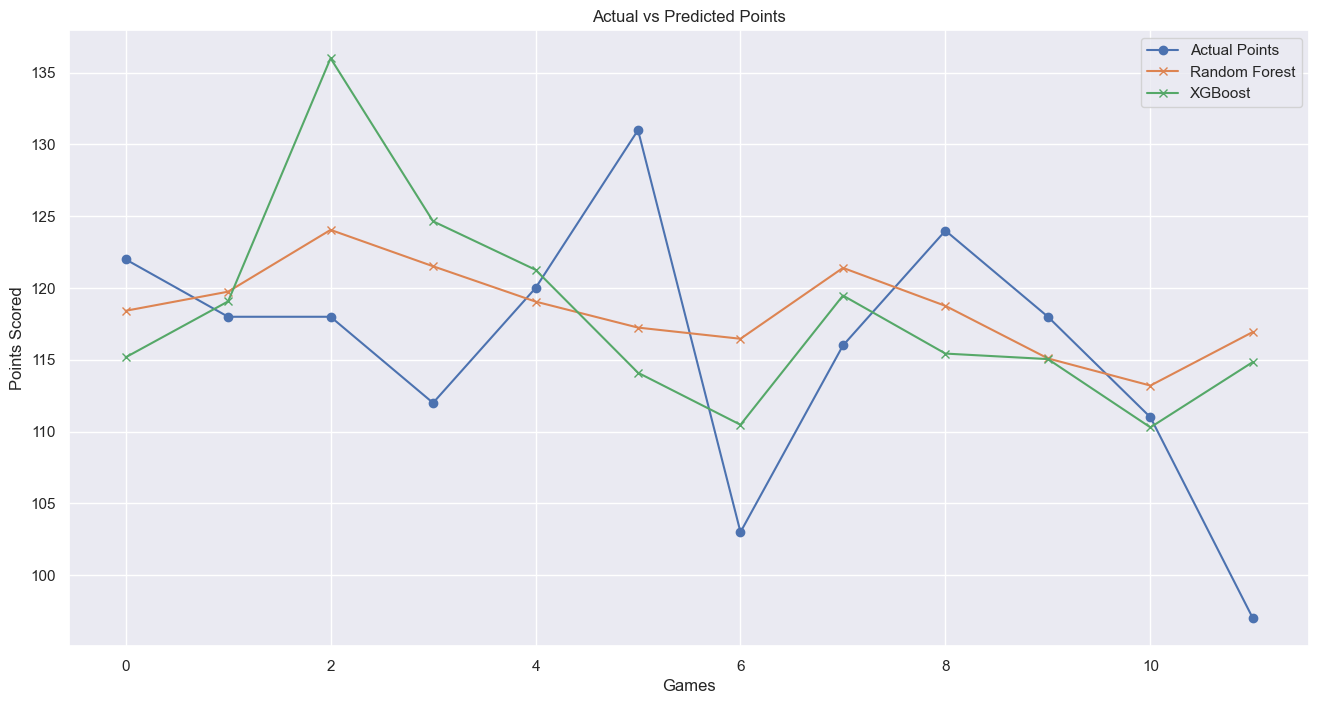

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
